In [ ]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (confusion_matrix,silhouette_score,classification_report  )
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("Country-data.csv")

In [ ]:
print(f"Shape : {df.shape}")
df.head()

Shape : (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
print("=== Info ===")
df.info()
print("\n=== Missing values ===")
print(df.isnull().sum())
print("\n=== Statistics ===")
df.describe().T

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

=== Missing values ===
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

=== Statistics ===


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


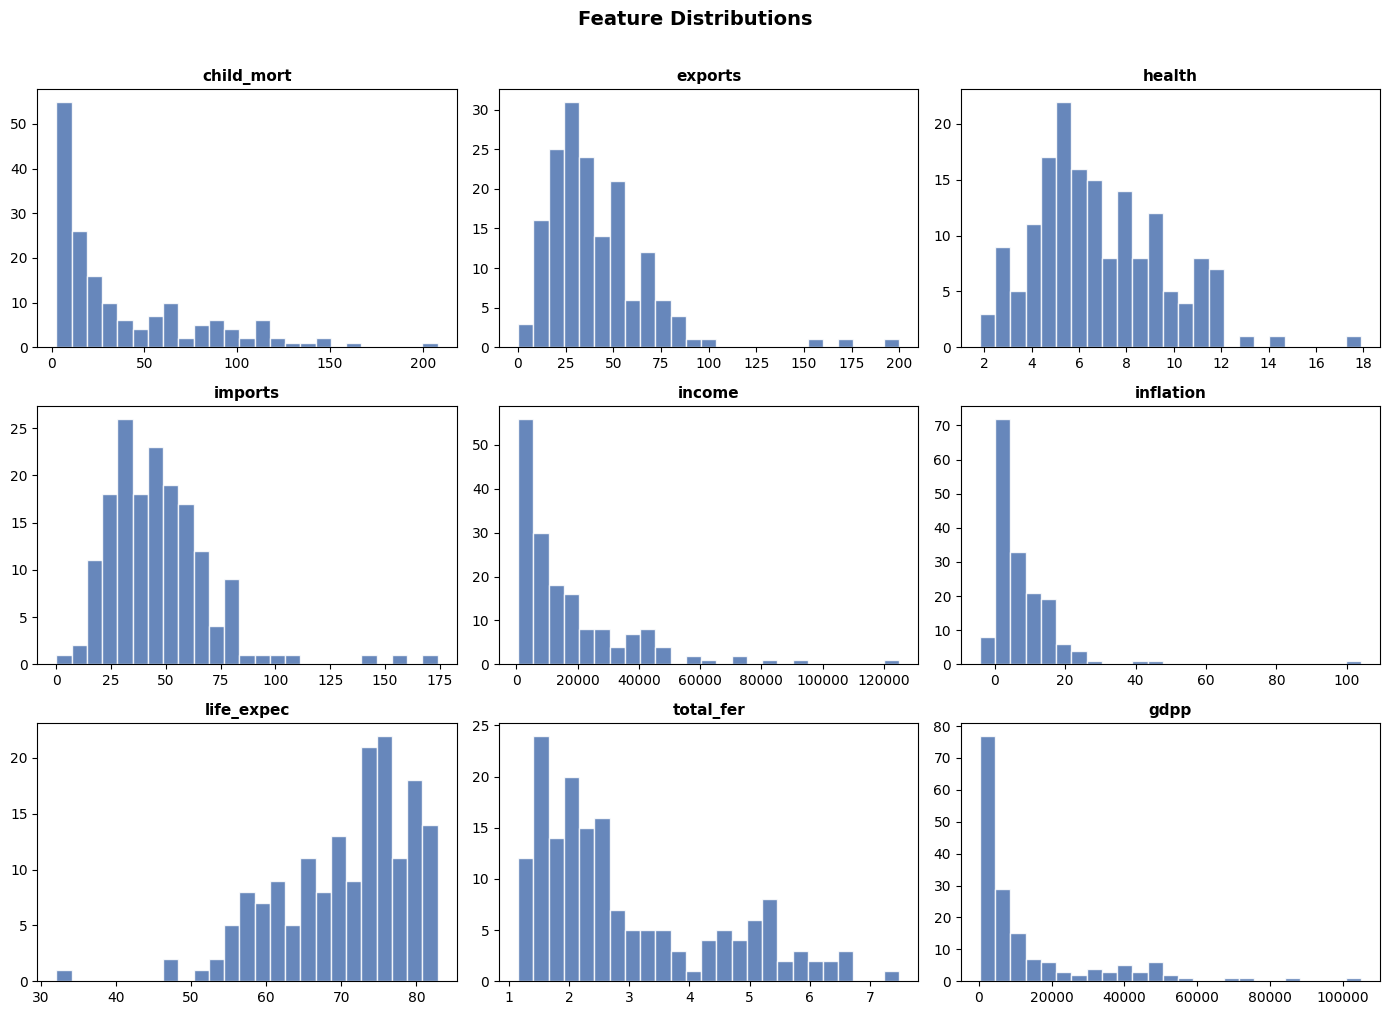

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols[:9]):
    axes[i].hist(df[col].dropna(), bins=25, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
plt.suptitle("Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


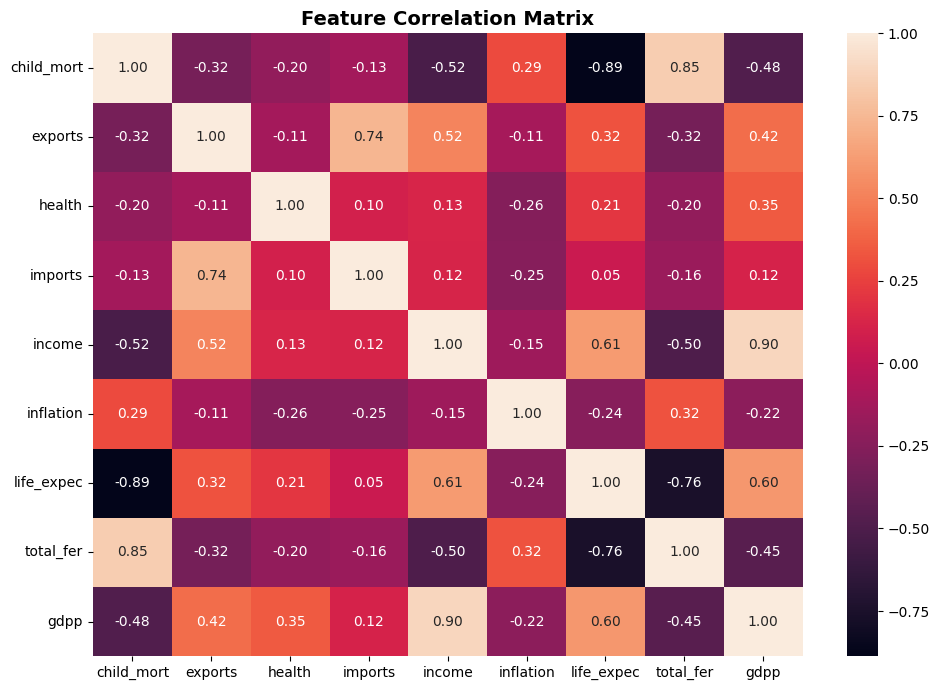

In [ ]:
plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


Tier distribution:
tier
Under-developed    79
Developing         49
Developed          39
Name: count, dtype: int64


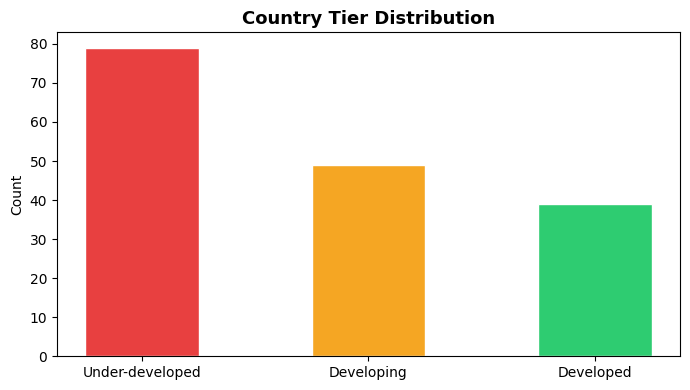

In [ ]:
def assign_tier(row):
    if row["gdpp"] > 15000 and row["life_expec"] > 75 and row["child_mort"] < 20:
        return 2   # Developed
    elif row["gdpp"] > 4000 and row["life_expec"] > 65:
        return 1   # Developing
    else:
        return 0   # Under-developed

df["tier"] = df.apply(assign_tier, axis=1)
tier_map = {0: "Under-developed", 1: "Developing", 2: "Developed"}

print("Tier distribution:")
print(df["tier"].value_counts().rename(tier_map))


fig, ax = plt.subplots(figsize=(7, 4))
counts = df["tier"].value_counts().sort_index()
bars = ax.bar([tier_map[i] for i in counts.index], counts.values,
              color=["#E84040","#F5A623","#2ECC71"], edgecolor="white", width=0.5)

ax.set_title("Country Tier Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
X = df.drop(columns=["country", "tier"])
y = df["tier"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (133, 9) | Test: (34, 9)


              precision    recall  f1-score   support

   Under-dev       1.00      1.00      1.00        16
  Developing       0.91      1.00      0.95        10
   Developed       1.00      0.88      0.93         8

    accuracy                           0.97        34
   macro avg       0.97      0.96      0.96        34
weighted avg       0.97      0.97      0.97        34



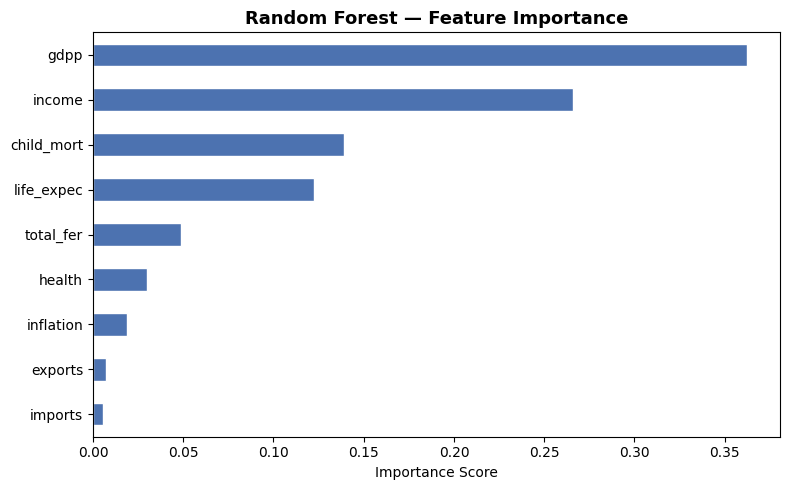

In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred,
      target_names=["Under-dev","Developing","Developed"]))

features = X.columns
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Random Forest — Feature Importance", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                    use_label_encoder=False, eval_metric="mlogloss",
                    random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print(classification_report(y_test, xgb_pred,
      target_names=["Under-dev","Developing","Developed"]))


              precision    recall  f1-score   support

   Under-dev       0.88      0.94      0.91        16
  Developing       0.89      0.80      0.84        10
   Developed       0.88      0.88      0.88         8

    accuracy                           0.88        34
   macro avg       0.88      0.87      0.88        34
weighted avg       0.88      0.88      0.88        34



               CV Mean  CV Std
Random Forest   0.9702  0.0186
XGBoost         0.9645  0.0343


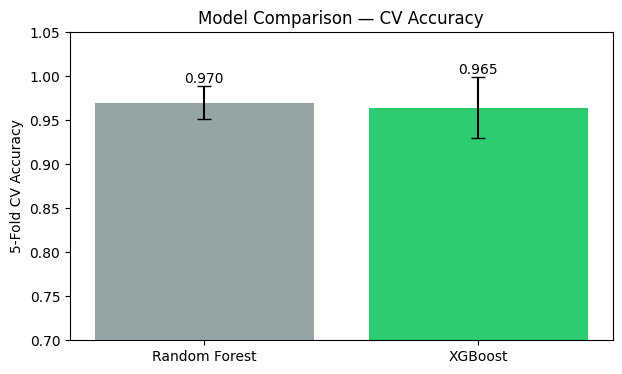

In [ ]:
from sklearn.model_selection import cross_val_score

models = {
    "Random Forest": rf,
    "XGBoost": xgb
}

results = {
    name: [
        cross_val_score(model, X_scaled, y, cv=5, scoring="accuracy").mean(),
        cross_val_score(model, X_scaled, y, cv=5, scoring="accuracy").std()
    ]
    for name, model in models.items()
}

results_df = pd.DataFrame(
    results,
    index=["CV Mean", "CV Std"]
).T.round(4)

print(results_df)

plt.figure(figsize=(7,4))
bars = plt.bar(
    results_df.index,
    results_df["CV Mean"],
    yerr=results_df["CV Std"],
    capsize=5,
    color=["#95A5A6", "#2ECC71"]
)

plt.bar_label(bars, fmt="%.3f")
plt.ylabel("5-Fold CV Accuracy")
plt.title("Model Comparison — CV Accuracy")
plt.ylim(0.7, 1.05)

plt.show()

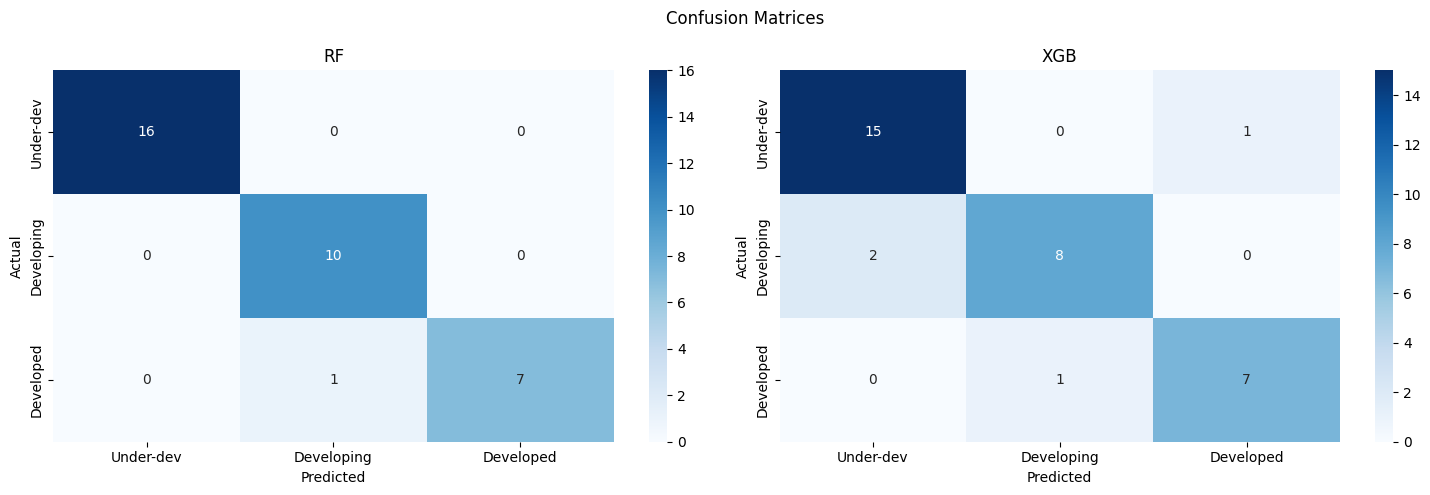

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ["Under-dev", "Developing", "Developed"]

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=labels,
    yticklabels=labels
)
axes[0].set_title("RF")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# XGBoost
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1],
    xticklabels=labels,
    yticklabels=labels
)
axes[1].set_title("XGB")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle("Confusion Matrices")
plt.tight_layout()
plt.show()

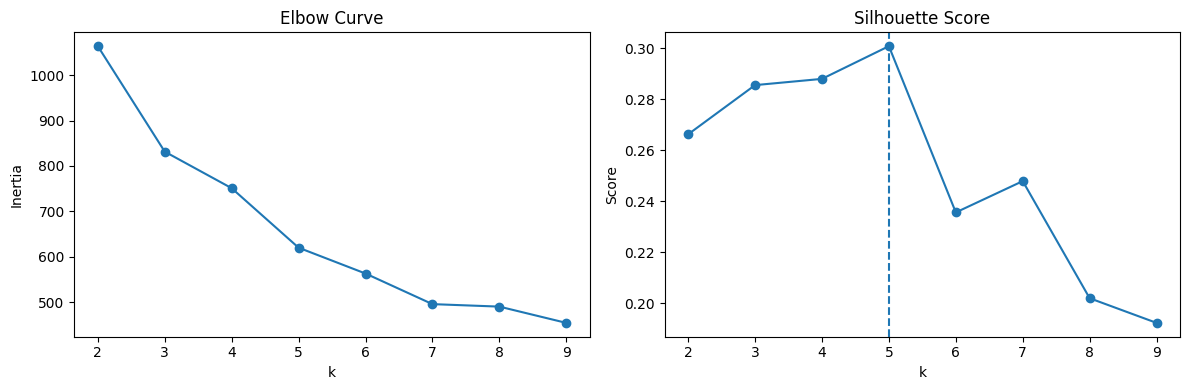

Best k: 5


In [ ]:
inertias = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = K_range[np.argmax(sil_scores)]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(K_range, inertias, marker="o")
plt.title("Elbow Curve")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, marker="o")
plt.axvline(best_k, linestyle="--")
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

print("Best k:", best_k)

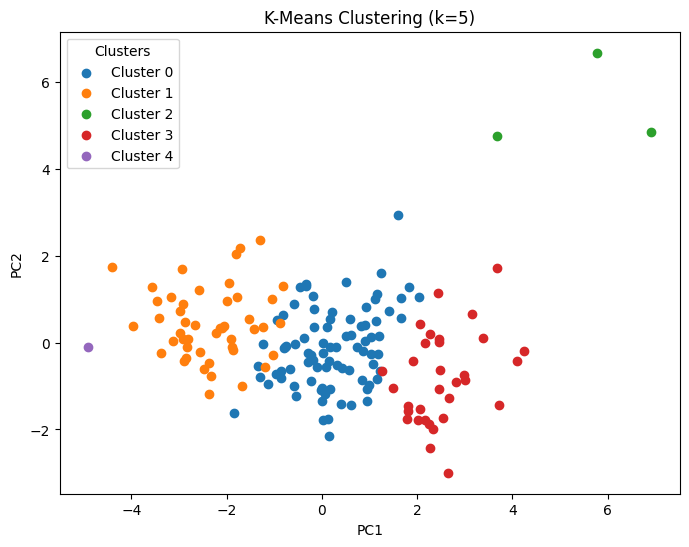

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["kmeans_cluster"] = km_final.fit_predict(X_scaled)

plt.figure(figsize=(8,6))

for cluster in range(best_k):
    mask = df["kmeans_cluster"] == cluster

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Cluster {cluster}"
    )

plt.title(f"K-Means Clustering (k={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Clusters")

plt.show()

In [ ]:
db = DBSCAN(eps=1.5, min_samples=5)

df["dbscan_cluster"] = db.fit_predict(X_scaled)

n_clusters = df["dbscan_cluster"].nunique() - (1 if -1 in df["dbscan_cluster"].values else 0)
n_noise = (df["dbscan_cluster"] == -1).sum()

print("Clusters found:", n_clusters)
print("Noise points:", n_noise)

print("\nCluster Distribution:")
print(df["dbscan_cluster"].value_counts().sort_index())

Clusters found: 1
Noise points: 30

Cluster Distribution:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


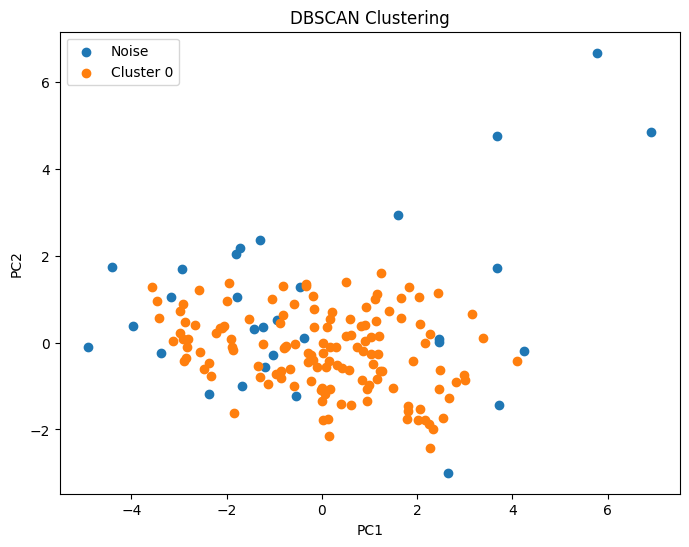

In [ ]:
plt.figure(figsize=(8,6))

for label in sorted(df["dbscan_cluster"].unique()):
    mask = df["dbscan_cluster"] == label

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label="Noise" if label == -1 else f"Cluster {label}"
    )

plt.title("DBSCAN Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend()

plt.show()

tier             0   1   2
kmeans_cluster            
0               32  47   5
1               46   1   0
2                0   0   3
3                0   1  31
4                1   0   0


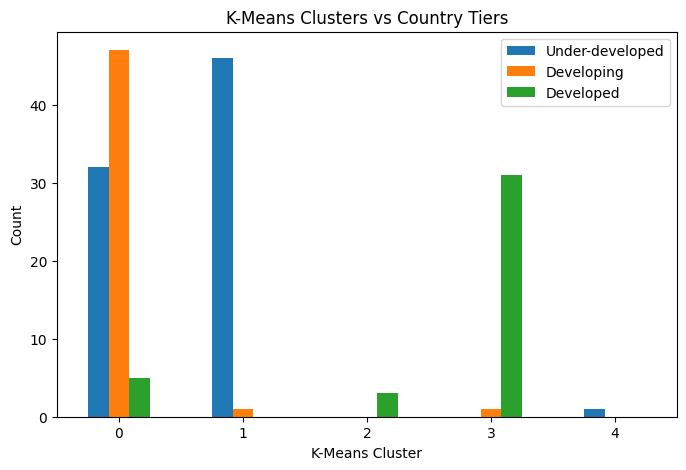

In [ ]:
cross_tab = pd.crosstab(df["kmeans_cluster"], df["tier"])

print(cross_tab)

cross_tab.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("K-Means Clusters vs Country Tiers")
plt.xlabel("K-Means Cluster")
plt.ylabel("Count")

plt.legend([
    "Under-developed",
    "Developing",
    "Developed"
])

plt.xticks(rotation=0)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

summary_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],

    "Test Accuracy": [
        round(accuracy_score(y_test, rf_pred), 3),
        round(accuracy_score(y_test, xgb_pred), 3)
    ],

    "CV Accuracy": [
        f"{results_df.loc['Random Forest','CV Mean']:.3f} ± {results_df.loc['Random Forest','CV Std']:.3f}",
        f"{results_df.loc['XGBoost','CV Mean']:.3f} ± {results_df.loc['XGBoost','CV Std']:.3f}"
    ]
})

print("\nMODEL SUMMARY")
print(summary_df)

print("\nK-Means Clusters:", best_k)
print("DBSCAN Clusters:", n_clusters)
print("Noise Points:", n_noise)


MODEL SUMMARY
           Model  Test Accuracy    CV Accuracy
0  Random Forest          0.971  0.970 ± 0.019
1        XGBoost          0.882  0.965 ± 0.034

K-Means Clusters: 5
DBSCAN Clusters: 1
Noise Points: 30
